### Installs and Imports

In [18]:
%pip install -q pandas
%pip install -q statsbombpy
%pip install -q networkx
%pip install -q matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

import warnings
from statsbombpy.api_client import NoAuthWarning

# Filter out the specific StatsBomb NoAuthWarning
warnings.simplefilter("ignore", NoAuthWarning)

# Now import/run statsbombpy cleanly without the warning
from statsbombpy import sb

# Display configuration for clean output inspection
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

/Users/lukebirkett/Repos/study-planner/981G5_Network_Science/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### Competition Extraction

In [2]:
# Retrieve the competitions DataFrame
competitions_df = sb.competitions()
print(f"Total Competitions Returned: {len(competitions_df)}")

# Filter the DataFrame for WSL 2023/2024
target_filter = (competitions_df['competition_id'] == 37) & (competitions_df['season_id'] == 281)
wsl_competition = competitions_df[target_filter].to_dict(orient='records')[0]

# Print the extracted row
print("\nExtracted Competition Payload:")
print(wsl_competition)

Total Competitions Returned: 80

Extracted Competition Payload:
{'competition_id': 37, 'season_id': 281, 'country_name': 'England', 'competition_name': "FA Women's Super League", 'competition_gender': 'female', 'competition_youth': False, 'competition_international': False, 'season_name': '2023/2024', 'match_updated': '2026-04-11T13:05:10.794831', 'match_updated_360': None, 'match_available_360': None, 'match_available': '2026-04-11T13:05:10.794831'}


### Helper Functions

In [3]:
def parse_minute(val, default_val=0):
    """Safely extracts the minute integer from a StatsBomb 'from' or 'to' timestamp."""
    if val is None:
        return default_val
    if isinstance(val, (int, float)):
        return int(val)
    if isinstance(val, str) and ':' in val:
        return int(val.split(':')[0])  # Take 'MM' from 'MM:SS'
    try:
        return int(val)
    except ValueError:
        return default_val

In [4]:
def extract_11_players(player_list):
    """Used to turn a teams match roster into an 11 player list"""
    sorted_players = sorted(player_list, key=lambda x: x['Minutes Played'], reverse=True)
    top_11_players = sorted_players[:11]
    return top_11_players

### Match Extractions

Here is the current implementation of the code. What I have done is code an implementation which will extract 2 lists for every match. The lists contain a match_id, team_name, and a list containing the active players from the match. This player listed contains all players that entered the field but it contains a minutes players field so later on I can filter down to the 11. The purpose of this data structure is to give me a list that I can loop through. Each list represents the basis of a network, i.e. the fields can be used to extract the passes from events and the player level info establish the nodes

In [5]:
# Fetch WSL 2023/2024 Matches
COMPETITION_ID = 37
SEASON_ID = 281

matches_df = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)
print(f"League contains {len(matches_df)} matches.")
match_records = []

for idx, match in matches_df.iterrows():
    m_id = match['match_id']
    events_df = sb.events(match_id=m_id)
    max_minute = int(events_df['minute'].max())
    lineups = sb.lineups(match_id=m_id)
    
    for team in lineups:
        roster = len(lineups[team]['player_id'].tolist())
        player_list = []

        # Extract Player Level Data
        for player_index in range(0,roster):
            if not lineups[team]['positions'][player_index]:
                pass
            else:
                start = lineups[team]['positions'][player_index][0]
                end = lineups[team]['positions'][player_index][-1]
                pos = start['position']
                # Started
                if start['start_reason'] == 'Starting XI':
                    started = 1
                    _from = 0
                    if start['end_reason'] == 'Final Whistle':
                        full_match = 1
                        to = max_minute
                    else:
                        if end['end_reason'] == 'Final Whistle':
                            full_match = 1
                            to = max_minute
                        else:
                            full_match = 0
                            to = parse_minute(end.get('to'), default_val=max_minute)
                # Didnt Start
                else: 
                    started = 0
                    _from = parse_minute(start.get('from'), default_val=max_minute)
                    if end['to']: # Didnt start and Didnt finish
                        to = parse_minute(end.get('to'), default_val=max_minute)
                    else:
                        to = max_minute
                    full_match = 0
                
                # player index
                pid = lineups[team]['player_id'].tolist()[player_index]
                pn = lineups[team]['player_name'].tolist()[player_index]

                player_dict = {
                    "Player Name": pn,
                    "Player ID": pid,
                    "Position": pos,
                    # "Started": started,
                    # "Full Match": full_match,
                    "Starting Minute": _from,
                    "Ending Minute": to,
                    "Minutes Played": (to-_from),
                }

                player_list.append(player_dict)

        match_records.append([idx, m_id, team, player_list])

League contains 132 matches.


In [7]:
print("Match Index", match_records[0][0])
print("Match ID", match_records[0][1])
print("Team Name", match_records[0][2])
print("Player List", match_records[0][3])

Match Index 0
Match ID 3913082
Team Name Brighton & Hove Albion WFC
Player List [{'Player Name': 'Maria Thorisdottir', 'Player ID': 4636, 'Position': 'Center Back', 'Starting Minute': 0, 'Ending Minute': 100, 'Minutes Played': 100}, {'Player Name': 'María Victoria Losada Gómez', 'Player ID': 10158, 'Position': 'Right Defensive Midfield', 'Starting Minute': 54, 'Ending Minute': 100, 'Minutes Played': 46}, {'Player Name': 'Tatiana Vanessa Ferreira Pinto', 'Player ID': 10167, 'Position': 'Left Midfield', 'Starting Minute': 95, 'Ending Minute': 100, 'Minutes Played': 5}, {'Player Name': 'Sophie Baggaley', 'Player ID': 16376, 'Position': 'Goalkeeper', 'Starting Minute': 0, 'Ending Minute': 100, 'Minutes Played': 100}, {'Player Name': 'Pauline Bremer', 'Player ID': 20725, 'Position': 'Left Wing', 'Starting Minute': 0, 'Ending Minute': 95, 'Minutes Played': 95}, {'Player Name': 'Katie Robinson', 'Player ID': 21059, 'Position': 'Right Wing Back', 'Starting Minute': 0, 'Ending Minute': 68, 'Min

### Match Supplementation (Total Passes and 11 Players)

In [8]:
integrated_match_records = []

for match_data in match_records:
    match_index, m_id, team_name, player_list = match_data
    
    events = sb.events(match_id=m_id)

    team_passes = events[
        (events['team'] == team_name) & 
        (events['type'] == 'Pass') & 
        (events['pass_outcome'].isna()) # successful pass
    ]

    total_team_passes = len(team_passes)

    extracted_players_list = extract_11_players(player_list)
    
    integrated_match_records.append([
        match_index, 
        m_id, 
        team_name, 
        total_team_passes, 
        player_list,
        extracted_players_list
    ])

sample_entry = integrated_match_records[0]

print("\nSample Enriched Match Record:")
print(f"Match Index:  {sample_entry[0]}")
print(f"Match ID:     {sample_entry[1]}")
print(f"Team Name:    {sample_entry[2]}")
print(f"Total Passes: {sample_entry[3]}")
print(f"Roster Count: {len(sample_entry[4])} players")
print(f"Active Count: {len(sample_entry[5])} players")
print("Top 3 Players in Roster:")
for p in sample_entry[5][:3]:
    print(f"  • {p['Player Name']} ({p['Position']}) - {p['Minutes Played']} mins")


Sample Enriched Match Record:
Match Index:  0
Match ID:     3913082
Team Name:    Brighton & Hove Albion WFC
Total Passes: 204
Roster Count: 16 players
Active Count: 11 players
Top 3 Players in Roster:
  • Maria Thorisdottir (Center Back) - 100 mins
  • Sophie Baggaley (Goalkeeper) - 100 mins
  • Emma Nanny Charlotte Kullberg (Left Wing Back) - 100 mins


### High-Level Statistics (Match and Passes)

In [9]:
total_matches = len(match_records)/2
total_team_games = len(match_records)

# Extract total unique active players per team per match (before truncation)
players_used_per_game = [len(m[3]) for m in match_records]

mean_players_used = np.mean(players_used_per_game)
min_players_used = np.min(players_used_per_game)
max_players_used = np.max(players_used_per_game)

# Calculate total season passes across all matches
total_passes = 0
passes_per_team_game = []

for match_data in integrated_match_records:
    match_index, m_id, team_name, total_team_passes, player_list, extracted_players_list = match_data
    
    pass_count = total_team_passes
    total_passes += pass_count
    passes_per_team_game.append(pass_count)

mean_passes = np.mean(passes_per_team_game)
min_passes = np.min(passes_per_team_game)
max_passes = np.max(passes_per_team_game)

# ==============================================================================
# 3. PRINT GENERATED TABLE STATS
# ==============================================================================
print("\n" + "=" * 60)
print("EXTRACTED SUMMARY STATISTICS (WSL 2023/2024)")
print("=" * 60)
print(f"Total Matches Analyzed:                 {total_matches}")
print(f"Total Team Match Networks:              {total_team_games}")
print(f"Total Completed Season Passes:          {total_passes:,}")
print(f"Mean Passes per Team per Match:         {mean_passes:.1f} (Range: {min_passes} - {max_passes})")
print(f"Mean Unique Players Used per Game:      {mean_players_used:.1f} (Range: {min_players_used} - {max_players_used})")
# print("=" * 60)


EXTRACTED SUMMARY STATISTICS (WSL 2023/2024)
Total Matches Analyzed:                 132.0
Total Team Match Networks:              264
Total Completed Season Passes:          105,262
Mean Passes per Team per Match:         398.7 (Range: 120 - 847)
Mean Unique Players Used per Game:      15.1 (Range: 12 - 16)


### Highest Pass Match

In [10]:
# Returns a tuple: (list_index, max_record)
max_idx, highest_pass_match = max(
    enumerate(integrated_match_records), 
    key=lambda item: item[1][3]
)

print(f"Record Index: {max_idx}")
print(f"Match ID:     {highest_pass_match[1]}")
print(f"Team:         {highest_pass_match[2]}")
print(f"Passes:       {highest_pass_match[3]}")

Record Index: 60
Match ID:     3913160
Team:         Arsenal WFC
Passes:       847


### Network

PassMap Graph Successfully Built for Arsenal WFC (Match ID: 3913160)
• Nodes: 11 | Edges: 89 | Total Filtered Passes: 720


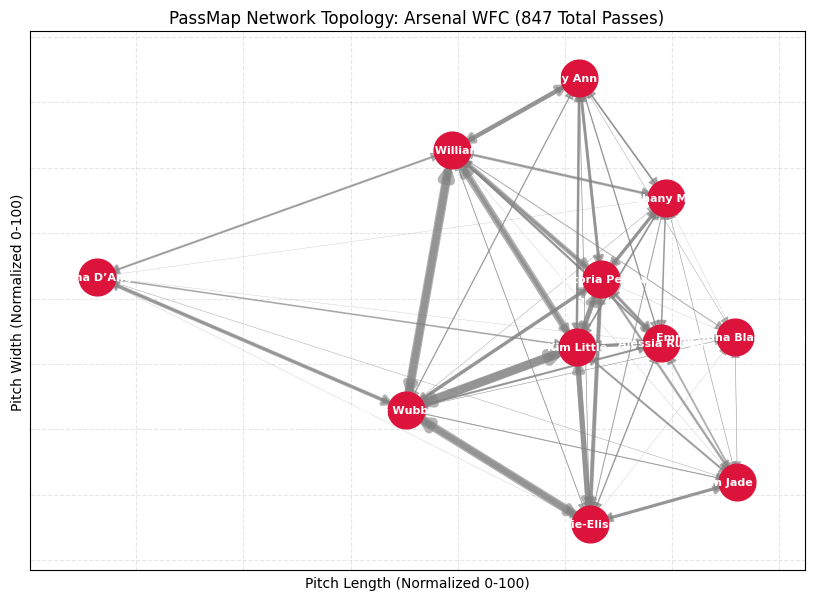

In [11]:
import networkx as nx
import matplotlib.pyplot as plt
from statsbombpy import sb

def build_passmap_network(match_record):
    """
    Constructs a weighted, directed NetworkX graph (nx.DiGraph) for a team passmap.
    
    Parameters:
        match_record (list): An entry from integrated_match_records in the format:
            [match_index, match_id, team_name, total_passes, player_list, top_11_players]
            
    Returns:
        G (nx.DiGraph): Directed graph where nodes are player names/IDs with spatial coordinates (x,y)
                        and edges represent completed pass counts between player pairs.
    """
    
    # Unpack record
    _, m_id, team_name, _, _, top_11_players = match_record
    
    # Extract Top-11 Player IDs and create a mapping for fast filtering
    top_11_ids = {p['Player ID'] for p in top_11_players}
    player_id_to_name = {p['Player ID']: p['Player Name'] for p in top_11_players}
    
    # Fetch event stream for the match
    events = sb.events(match_id=m_id)
    
    # Filter for successful passes belonging exclusively to the target team and Top-11 players
    passes_df = events[
        (events['team'] == team_name) & 
        (events['type'] == 'Pass') & 
        (events['pass_outcome'].isna()) &
        (events['player_id'].isin(top_11_ids)) & 
        (events['pass_recipient_id'].isin(top_11_ids))
    ].copy()
    
    # Calculate Average Spatial Location (x, y) for each Top-11 player
    # This is the Node location in the pitch
    # Split StatsBomb 'location' list [x, y] into separate normalized coordinates (0-100 scale)
    passes_df['x'] = passes_df['location'].apply(lambda loc: (loc[0] / 120.0) * 100 if isinstance(loc, list) else None)
    passes_df['y'] = passes_df['location'].apply(lambda loc: (loc[1] / 80.0) * 100 if isinstance(loc, list) else None)
    avg_locations = passes_df.groupby('player_id')[['x', 'y']].mean().to_dict('index')
    
    # Initialize NetworkX Directed Graph
    G = nx.DiGraph()
    
    # Add Nodes with attributes (Name, Position, Average x,y)
    for p in top_11_players:
        p_id = p['Player ID']
        p_name = p['Player Name']
        p_pos = p['Position']
        loc = avg_locations.get(p_id, {'x': 50.0, 'y': 50.0})
        
        G.add_node(
            p_name,
            player_id=p_id,
            position=p_pos,
            pos=(loc['x'], loc['y']), # Position tuple for NetworkX layout
            x=loc['x'],
            y=loc['y']
        )
        
    # Aggregate Edges (Pass Volume between pairs)
    pass_counts = passes_df.groupby(['player_id', 'pass_recipient_id']).size().reset_index(name='weight')
    
    for _, row in pass_counts.iterrows():
        passer_name = player_id_to_name[row['player_id']]
        recipient_name = player_id_to_name[row['pass_recipient_id']]
        pass_volume = int(row['weight'])
        
        G.add_edge(passer_name, recipient_name, weight=pass_volume)
        
    print(f"PassMap Graph Successfully Built for {team_name} (Match ID: {m_id})")
    print(f"• Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()} | Total Filtered Passes: {passes_df.shape[0]}")
    
    return G

# ==============================================================================
# EXECUTION & PLOTTING SHOWCASE
# ==============================================================================
# Build graph for the highest passing match (Record Index 60: Arsenal WFC with 847 passes)
G_arsenal = build_passmap_network(highest_pass_match)

# Plot network layout using NetworkX
plt.figure(figsize=(10, 7))

# Get node positions from attributes
pos = nx.get_node_attributes(G_arsenal, 'pos')
weights = [G_arsenal[u][v]['weight'] / 5.0 for u, v in G_arsenal.edges()] # Scale edge widths

# Draw nodes and edges
nx.draw_networkx_nodes(G_arsenal, pos, node_size=700, node_color='crimson')
nx.draw_networkx_edges(G_arsenal, pos, width=weights, edge_color='gray', alpha=0.6, arrowsize=15)
nx.draw_networkx_labels(G_arsenal, pos, font_size=8, font_color='white', font_weight='bold')

plt.title(f"PassMap Network Topology: Arsenal WFC ({highest_pass_match[3]} Total Passes)", fontsize=12)
plt.xlabel("Pitch Length (Normalized 0-100)")
plt.ylabel("Pitch Width (Normalized 0-100)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

### Pitch Plotting Function

In [99]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, Arc
import networkx as nx

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, Arc
import networkx as nx

# ==============================================================================
# 1. PURE MATPLOTLIB VERTICAL PITCH DRAWING (FIXED PATCH SYNTAX)
# ==============================================================================
def draw_vertical_pitch(ax=None, pitch_color='#f4f6f4', line_color='#708090'):
    """
    Draws a vertical football pitch on a 100x100 relative coordinate grid.
    
    Coordinates:
    - X (0 to 100): Horizontal Axis (Width - Touchline to Touchline)
    - Y (0 to 100): Vertical Axis (Length - Goal to Goal)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 11))
        
    ax.set_facecolor(pitch_color)
    
    # 1. Outer Boundary & Halfway Line
    ax.add_patch(Rectangle((0, 0), 100, 100, fill=False, edgecolor=line_color, lw=2))
    ax.plot([0, 100], [50, 50], color=line_color, lw=1.5)
    
    # Center circle & spot
    ax.add_patch(Circle((50, 50), 12, fill=False, edgecolor=line_color, lw=1.5))
    ax.add_patch(Circle((50, 50), 0.8, fill=True, color=line_color))

    # 2. Defensive End (Bottom / GK Area)
    ax.add_patch(Rectangle((20, 0), 60, 18, fill=False, edgecolor=line_color, lw=1.5))
    ax.add_patch(Rectangle((36, 0), 28, 6, fill=False, edgecolor=line_color, lw=1.5))
    ax.add_patch(Circle((50, 12), 0.8, fill=True, color=line_color))
    ax.add_patch(Arc((50, 18), width=20, height=20, angle=0, theta1=0, theta2=180, color=line_color, lw=1.5))

    # 3. Attacking End (Top)
    ax.add_patch(Rectangle((20, 82), 60, 18, fill=False, edgecolor=line_color, lw=1.5))
    ax.add_patch(Rectangle((36, 94), 28, 6, fill=False, edgecolor=line_color, lw=1.5))
    ax.add_patch(Circle((50, 88), 0.8, fill=True, color=line_color))
    ax.add_patch(Arc((50, 82), width=20, height=20, angle=0, theta1=180, theta2=360, color=line_color, lw=1.5))

    # 4. Corner Arcs
    ax.add_patch(Arc((0, 0), width=6, height=6, angle=0, theta1=0, theta2=90, color=line_color, lw=1.5))
    ax.add_patch(Arc((100, 0), width=6, height=6, angle=0, theta1=90, theta2=180, color=line_color, lw=1.5))
    ax.add_patch(Arc((0, 100), width=6, height=6, angle=0, theta1=270, theta2=360, color=line_color, lw=1.5))
    ax.add_patch(Arc((100, 100), width=6, height=6, angle=0, theta1=180, theta2=270, color=line_color, lw=1.5))

    # 5. Axis Limits & Formatting
    ax.set_xlim(-5, 105)
    ax.set_ylim(-5, 105)
    ax.set_aspect('equal')
    ax.axis('off')
    
    return ax

<Axes: >

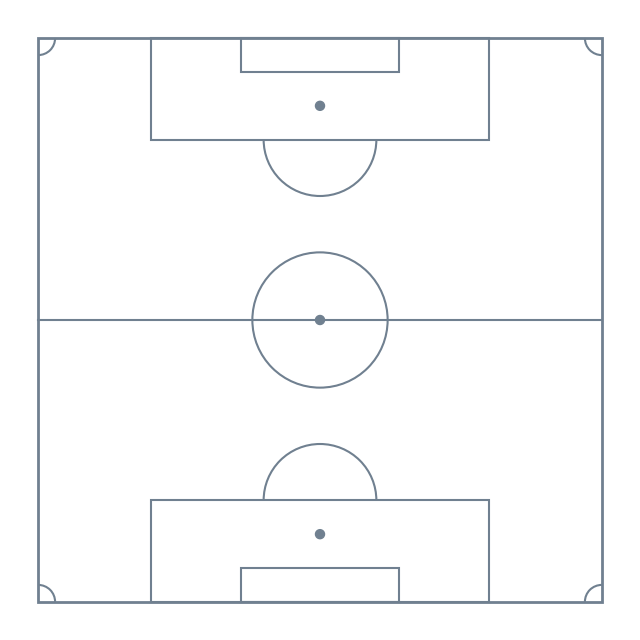

In [100]:
draw_vertical_pitch()

### PassMap Network on Pitch

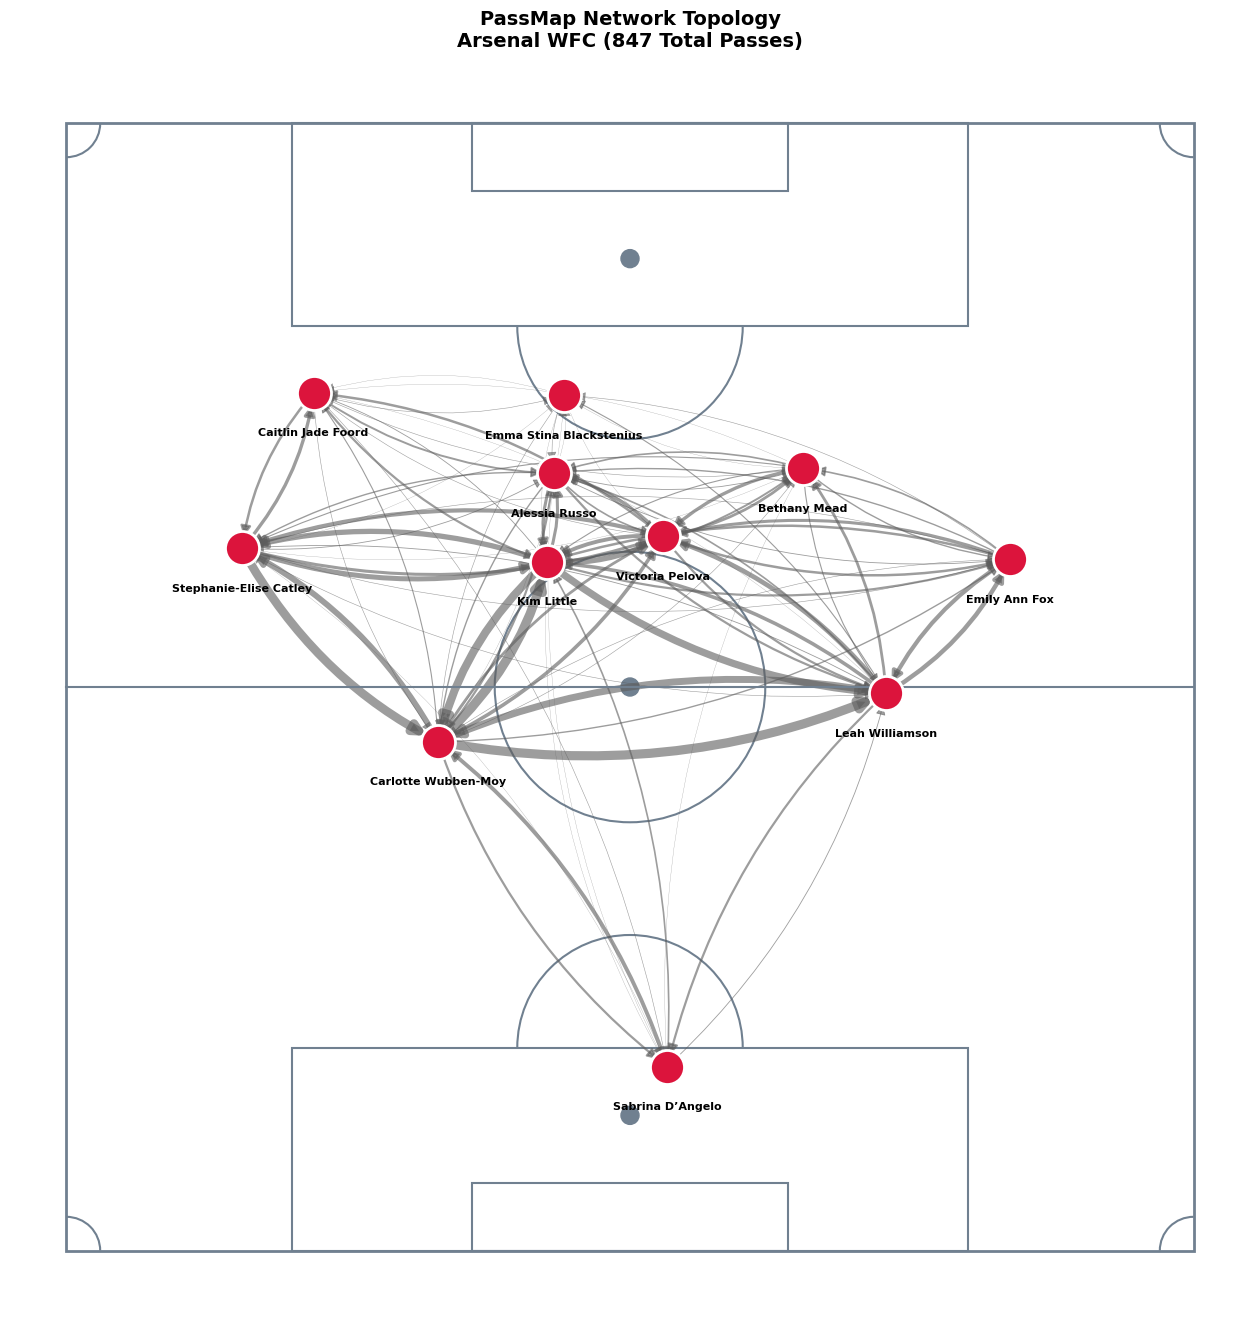

In [68]:
def plot_passmap_on_pitch(G, team_name, total_passes):
    """
    Overlays a NetworkX passmap graph onto the custom vertical pitch.
    """
    fig, ax = plt.subplots(figsize=(16, 22), facecolor='#ffffff')
    
    # 1. Draw the pitch background
    draw_vertical_pitch(ax=ax)
    
    # 2. Corrected Map Coordinates:
    # Horizontal Axis = Width (data['y'])
    # Vertical Axis   = Length (data['x']) -> Puts GK (x~0) at bottom, Strikers at top
    pos_vertical = {node: (data['y'], data['x']) for node, data in G.nodes(data=True)}
    
    # 3. Create offset position for text labels
    label_pos = {node: (coords[0], coords[1] - 3.5) for node, coords in pos_vertical.items()}
    
    # 4. Scale edge weights for arrow width
    edges = G.edges()
    weights = [G[u][v]['weight'] / 5.0 for u, v in edges]
    
    # 5. Draw Edges with Curvature
    nx.draw_networkx_edges(
        G, pos_vertical, 
        ax=ax,
        edge_color='#5c5c5c',
        alpha=0.6,
        width=weights,
        arrowsize=15,
        connectionstyle="arc3,rad=0.15" 
    )
    
    # 6. Draw Player Nodes
    nx.draw_networkx_nodes(
        G, pos_vertical, 
        ax=ax,
        node_size=600, 
        node_color='crimson',
        edgecolors='white',
        linewidths=2
    )
    
    # 7. Draw Player Name Labels
    nx.draw_networkx_labels(
        G, label_pos, 
        ax=ax,
        font_size=8, 
        font_color='black', 
        font_weight='bold'
    )
    
    # 8. Title
    plt.title(f"PassMap Network Topology\n{team_name} ({total_passes} Total Passes)", 
              fontsize=14, fontweight='bold', color='black', pad=15)
    
    plt.show()

# ==============================================================================
# EXECUTION
# ==============================================================================
plot_passmap_on_pitch(G_arsenal, highest_pass_match[2], highest_pass_match[3])

### Adjacency Matrix

In [69]:
import networkx as nx
import pandas as pd

# Convert to a labeled Pandas DataFrame
adj_df = nx.to_pandas_adjacency(G_arsenal, weight='weight', dtype=int)

print(adj_df)

                         Stephanie-Elise Catley  Sabrina D’Angelo  Emma Stina Blackstenius  Kim Little  Alessia Russo  Carlotte Wubben-Moy  Victoria Pelova  Leah Williamson  Emily Ann Fox  Caitlin Jade Foord  Bethany Mead
Stephanie-Elise Catley                        0                 0                        1          18              3                   31               11                2              2                  12             1
Sabrina D’Angelo                              1                 0                        0           6              0                   14                0                3              0                   2             0
Emma Stina Blackstenius                       0                 0                        0           1              2                    2                1                0              0                   1             1
Kim Little                                   19                 1                        0           0          

In [72]:
import networkx as nx

# Convert the weighted directed graph to a dense NumPy adjacency matrix
adj_matrix = nx.to_numpy_array(G_arsenal, weight='weight')

print(adj_matrix)

[[ 0.  0.  1. 18.  3. 31. 11.  2.  2. 12.  1.]
 [ 1.  0.  0.  6.  0. 14.  0.  3.  0.  2.  0.]
 [ 0.  0.  0.  1.  2.  2.  1.  0.  0.  1.  1.]
 [19.  1.  0.  0. 11. 29. 19. 26.  8.  3.  7.]
 [ 5.  1.  1. 11.  0.  5.  6.  8.  3.  0.  3.]
 [21.  8.  1. 33.  8.  0. 13. 33.  5.  4.  2.]
 [15.  0.  0. 14. 12. 10.  0.  8.  9.  9. 10.]
 [ 3.  8.  4. 13.  6. 25. 17.  0. 16.  1. 10.]
 [ 2.  0.  2.  9.  5.  2. 11. 15.  0.  0.  6.]
 [ 9.  0.  2.  8.  7.  2.  2.  0.  0.  0.  2.]
 [ 4.  1.  0.  4.  6.  0. 12.  4.  5.  1.  0.]]


### Degree Analysis

In [85]:
import numpy as np
import pandas as pd
import networkx as nx

def analyze_degree_and_heterogeneity(G, top_n_hubs=5):
    """
    Computes player-level degree/strength metrics, team-level Freeman Centralization,
    macro network heterogeneity statistics, and top hub rankings for a passing network.
    
    Parameters:
        G (nx.DiGraph): Directed NetworkX graph with 'weight' edge attributes.
        top_n_hubs (int): Number of top hubs to extract.
        
    Returns:
        metrics_df (pd.DataFrame): Player-level metric calculations.
        macro_metrics (dict): Team-level centralization and heterogeneity stats.
        hubs_df (pd.DataFrame): Rank-ordered table of top hub players.
    """
    nodes = list(G.nodes())
    N = len(nodes)
    
    # -------------------------------------------------------------------------
    # 1. PLAYER-LEVEL DEGREE & STRENGTH METRICS
    # -------------------------------------------------------------------------
    in_degree = dict(G.in_degree())
    out_degree = dict(G.out_degree())
    in_strength = dict(G.in_degree(weight='weight'))
    out_strength = dict(G.out_degree(weight='weight'))
    total_degree = dict(G.degree())
    
    player_metrics = []
    
    for node in nodes:
        k_in = in_degree[node]
        k_out = out_degree[node]
        s_in = in_strength[node]
        s_out = out_strength[node]
        s_tot = s_in + s_out
        
        # Directional Asymmetry
        net_flow = s_out - s_in
        pass_ratio = s_out / s_in if s_in > 0 else np.nan
            
        player_metrics.append({
            "Player": node,
            "Position": G.nodes[node].get("position", "N/A"),
            "k_in (In-Degree)": k_in,
            "k_out (Out-Degree)": k_out,
            "s_in (Passes Rec.)": s_in,
            "s_out (Passes Comp.)": s_out,
            "Total Volume (s_tot)": s_tot,
            "Net Flow (Δs_i)": net_flow,
            "Pass Ratio (s_out / s_in)": round(pass_ratio, 2)
        })
        
    metrics_df = pd.DataFrame(player_metrics).set_index("Player")
    metrics_df = metrics_df.sort_values(by="Total Volume (s_tot)", ascending=False)

    # -------------------------------------------------------------------------
    # NETWORK HETEROGENEITY METRICS
    # -------------------------------------------------------------------------
    degrees = np.array(list(total_degree.values()))
    mean_k = np.mean(degrees) if N > 0 else 0
    var_k = np.var(degrees) if N > 0 else 0
    std_k = np.std(degrees) if N > 0 else 0
    second_moment = np.mean(degrees**2) if N > 0 else 0
    
    cv_k = std_k / mean_k if mean_k > 0 else 0
    norm_second_moment = second_moment / mean_k if mean_k > 0 else 0
    
    macro_metrics = {
        # Centralization Stats
        "Team Node Volume Variance Var(s_tot)": float(np.var(metrics_df["Total Volume (s_tot)"])),
        # Heterogeneity Stats
        "Mean Unweighted Degree <k>": float(mean_k),
        "Degree Variance Var(k)": float(var_k),
        "Degree Std Dev σ_k": float(std_k),
        "Second Moment <k^2>": float(second_moment),
        "Coefficient of Variation (CV_k)": float(cv_k),
        "Normalized Second Moment (<k^2> / <k>)": float(norm_second_moment)
    }
    
    # -------------------------------------------------------------------------
    # 4. HUB DETECTION (Rank-Ordered by Pass Volume)
    # -------------------------------------------------------------------------
    mean_s_tot = metrics_df["Total Volume (s_tot)"].mean()
    
    hubs_df = metrics_df.reset_index()[
        ["Player", "Position", "Total Volume (s_tot)", "k_in (In-Degree)", "k_out (Out-Degree)"]
    ].head(top_n_hubs).copy()
    
    hubs_df.insert(0, "Rank", range(1, len(hubs_df) + 1))
    hubs_df["Relative Volume (s_i / <s_tot>)"] = (hubs_df["Total Volume (s_tot)"] / mean_s_tot).round(2) if mean_s_tot > 0 else 0
    
    return metrics_df, macro_metrics, hubs_df

In [86]:
# =============================================================================
# EXECUTION FOR SECTION 4.1 CASE STUDY (Arsenal WFC)
# =============================================================================

# Analyze graph using the integrated function
player_df, macro_stats, top_hubs_df = analyze_degree_and_heterogeneity(G_arsenal, top_n_hubs=5)

# 1. Player-Level Table
print("\n" + "="*90)
print("#### 4.1. Micro-Level Execution: Player-Level Degree Metrics (Arsenal WFC)")
print("="*90)
print(player_df.to_string())

# 2. Macro Network Metrics
print("\n" + "="*60)
print("Macro-Level Metrics: Centralization & Network Heterogeneity")
print("="*60)
for metric_name, val in macro_stats.items():
    print(f"{metric_name:<45}: {val:.4f}")

# 3. Top Network Hubs
print("\n" + "="*60)
print("Top Network Hubs (Rank-Ordered)")
print("="*60)
print(top_hubs_df.to_string(index=False))


#### 4.1. Micro-Level Execution: Player-Level Degree Metrics (Arsenal WFC)
                                          Position  k_in (In-Degree)  k_out (Out-Degree)  s_in (Passes Rec.)  s_out (Passes Comp.)  Total Volume (s_tot)  Net Flow (Δs_i)  Pass Ratio (s_out / s_in)
Player                                                                                                                                                                                              
Carlotte Wubben-Moy               Left Center Back                 9                  10                 120                   128                   248                8                       1.07
Kim Little                 Left Defensive Midfield                10                   9                 117                   123                   240                6                       1.05
Leah Williamson                  Right Center Back                 8                  10                  99                   103      

### Average Shortest Path

In [88]:
import numpy as np
import pandas as pd
import networkx as nx

def calculate_average_shortest_path(G):
    """
    Computes the inverted distance matrix, all-pairs shortest path matrix, 
    and global average shortest path length (d) using Dijkstra's algorithm.
    
    Parameters:
        G (nx.DiGraph): Directed NetworkX graph with 'weight' edge attributes.
        
    Returns:
        d_global (float): Team-wide average shortest path length.
        distance_matrix_df (pd.DataFrame): N x N matrix of shortest topological distances (p_ij).
        player_path_df (pd.DataFrame): Player-level mean outgoing and incoming path lengths.
    """
    # 1. Create a copy to avoid mutating the original graph
    G_dist = G.copy()
    
    # 2. Add inverted weight transformation: l_ij = 1 / w_ij
    for u, v, data in G_dist.edges(data=True):
        weight = data.get('weight', 1)
        if weight > 0:
            data['distance'] = 1.0 / weight
        else:
            data['distance'] = np.inf

    # 3. Compute All-Pairs Shortest Paths via Dijkstra's Algorithm
    # dict of dicts: path_lengths[source][target] = distance
    path_lengths = dict(nx.all_pairs_dijkstra_path_length(G_dist, weight='distance'))
    
    # Convert path lengths into an N x N DataFrame (p_ij matrix)
    nodes = list(G_dist.nodes())
    distance_matrix_df = pd.DataFrame(index=nodes, columns=nodes, dtype=float)
    
    for src in nodes:
        for tgt in nodes:
            if src == tgt:
                distance_matrix_df.loc[src, tgt] = 0.0
            else:
                # If path exists, store length; otherwise np.nan (unreachable)
                distance_matrix_df.loc[src, tgt] = path_lengths.get(src, {}).get(tgt, np.nan)
                
    # 4. Compute Global Average Shortest Path Length (d)
    # Exclude diagonal (i == j)
    off_diagonal_mask = ~np.eye(len(nodes), dtype=bool)
    valid_distances = distance_matrix_df.values[off_diagonal_mask]
    
    # Filter out any unobserved/infinite paths (if graph is not strongly connected)
    valid_distances = valid_distances[~np.isnan(valid_distances)]
    
    d_global = np.mean(valid_distances)
    
    # 5. Extract Player-Level Path Averages (Outward reachability vs. Inward accessibility)
    # Mean Outgoing Path: How efficiently player_i can reach all other teammates
    # Mean Incoming Path: How efficiently all other teammates can reach player_i
    player_paths = []
    for player in nodes:
        # Exclude self-distance (0.0)
        out_paths = [distance_matrix_df.loc[player, tgt] for tgt in nodes if tgt != player]
        in_paths = [distance_matrix_df.loc[src, player] for src in nodes if src != player]
        
        player_paths.append({
            "Player": player,
            "Position": G.nodes[player].get("position", "N/A"),
            "Mean Outward Path Length (d_out)": np.mean(out_paths),
            "Mean Inward Path Length (d_in)": np.mean(in_paths)
        })
        
    player_path_df = pd.DataFrame(player_paths).set_index("Player")
    player_path_df = player_path_df.sort_values(by="Mean Outward Path Length (d_out)")
    
    return d_global, distance_matrix_df, player_path_df

In [89]:
# =============================================================================
# EXECUTION & VALIDATION (Arsenal WFC Case Study)
# =============================================================================

d_global_arsenal, dist_matrix_df, player_path_df = calculate_average_shortest_path(G_arsenal)

print("\n" + "="*80)
print(f"Part 1: Global Team Circulation Distance (d) - Arsenal WFC")
print("="*80)
print(f"Global Average Shortest Path Length (d): {d_global_arsenal:.4f} topological units")

print("\n" + "="*80)
print("Player-Level Path Length Summary (Ranked by Outward Efficiency)")
print("="*80)
print(player_path_df.to_string())


Part 1: Global Team Circulation Distance (d) - Arsenal WFC
Global Average Shortest Path Length (d): 0.1884 topological units

Player-Level Path Length Summary (Ranked by Outward Efficiency)
                                          Position  Mean Outward Path Length (d_out)  Mean Inward Path Length (d_in)
Player                                                                                                              
Carlotte Wubben-Moy               Left Center Back                          0.106572                        0.133478
Kim Little                 Left Defensive Midfield                          0.109245                        0.134141
Leah Williamson                  Right Center Back                          0.110634                        0.142160
Stephanie-Elise Catley                   Left Back                          0.122852                        0.148014
Victoria Pelova           Right Defensive Midfield                          0.133628                       

### Betweenness

In [90]:
import numpy as np
import pandas as pd
import networkx as nx

def calculate_betweenness_centrality(G, distance_matrix_df=None):
    """
    Computes weighted shortest-path betweenness centrality for a directed passing network.
    
    Parameters:
        G (nx.DiGraph): Directed NetworkX graph with 'weight' edge attributes.
        distance_matrix_df (pd.DataFrame, optional): Pre-computed distance matrix from Part 1.
        
    Returns:
        betweenness_df (pd.DataFrame): Player-level betweenness centrality scores.
    """
    # 1. Create a copy of the graph to ensure the distance attribute is present
    G_dist = G.copy()
    
    for u, v, data in G_dist.edges(data=True):
        weight = data.get('weight', 1)
        if weight > 0:
            data['distance'] = 1.0 / weight
        else:
            data['distance'] = np.inf

    # 2. Calculate Weighted Betweenness Centrality using shortest paths (normalized=True by default)
    # NetworkX automatically accounts for directed edges and path weights.
    betweenness_dict = nx.betweenness_centrality(G_dist, weight='distance', normalized=True)
    
    # 3. Compile into a DataFrame
    nodes = list(G_dist.nodes())
    betweenness_data = []
    
    for node in nodes:
        betweenness_data.append({
            "Player": node,
            "Position": G.nodes[node].get("position", "N/A"),
            "Betweenness Centrality g(i)": betweenness_dict.get(node, 0.0)
        })
        
    betweenness_df = pd.DataFrame(betweenness_data).set_index("Player")
    
    # Sort by betweenness score descending (highest bridge/control value first)
    betweenness_df = betweenness_df.sort_values(by="Betweenness Centrality g(i)", ascending=False)
    
    return betweenness_df


# =============================================================================
# EXECUTION & VALIDATION (Arsenal WFC Case Study)
# =============================================================================

betweenness_df = calculate_betweenness_centrality(G_arsenal)

print("\n" + "="*80)
print("Part 2: Betweenness Centrality Analysis - Arsenal WFC")
print("="*80)
print(betweenness_df.to_string())


Part 2: Betweenness Centrality Analysis - Arsenal WFC
                                          Position  Betweenness Centrality g(i)
Player                                                                         
Carlotte Wubben-Moy               Left Center Back                     0.322222
Leah Williamson                  Right Center Back                     0.300000
Kim Little                 Left Defensive Midfield                     0.177778
Victoria Pelova           Right Defensive Midfield                     0.138889
Stephanie-Elise Catley                   Left Back                     0.122222
Sabrina D’Angelo                        Goalkeeper                     0.000000
Emma Stina Blackstenius             Center Forward                     0.000000
Alessia Russo            Center Attacking Midfield                     0.000000
Emily Ann Fox                           Right Back                     0.000000
Caitlin Jade Foord                       Left Wing               

### Clustering (Cyclical)

In [92]:
import numpy as np
import pandas as pd
import networkx as nx

def calculate_ahnert_clustering(G):
    """
    Computes local and global directed weighted clustering coefficients 
    following the Ahnert et al. (2007) geometric mean formulation.
    
    Parameters:
        G (nx.DiGraph): Directed NetworkX graph with 'weight' edge attributes.
        
    Returns:
        global_Cw (float): Team-wide average weighted clustering coefficient.
        clustering_df (pd.DataFrame): Player-level local clustering scores C_w(i).
    """
    nodes = list(G.nodes())
    N = len(nodes)
    
    # 1. Extract Adjacency Matrix & Weight Matrix W
    W = nx.to_numpy_array(G, nodelist=nodes, weight='weight')
    A = (W > 0).astype(float) # Unweighted binary adjacency matrix
    
    # Max weight normalization
    w_max = np.max(W) if np.max(W) > 0 else 1.0
    W_norm = W / w_max
    
    # 2. Ahnert Element-Wise Geometric Transformation: W^(1/3)
    W_cube_root = np.cbrt(W_norm)
    
    # 3. Calculate Directed Triads for each node
    # Symmetrized cube root matrix: S = W^(1/3) + (W^T)^(1/3)
    S = W_cube_root + W_cube_root.T
    S_cubed = np.linalg.matrix_power(S, 3)
    
    # 4. Compute Unweighted Degree Terms for Denominator
    in_degree = np.sum(A, axis=0)
    out_degree = np.sum(A, axis=1)
    tot_degree = in_degree + out_degree
    
    # Reciprocal (bilateral) connections matrix
    A_recip = A * A.T
    d_recip = np.sum(A_recip, axis=1)
    
    local_Cw = {}
    
    for idx, node in enumerate(nodes):
        d_tot = tot_degree[idx]
        d_double = d_recip[idx]
        
        # Max possible directed triplets centered on node i
        denom = 2 * (d_tot * (d_tot - 1) - 2 * d_double)
        
        if denom > 0:
            # Numerator is 1/8 * (S^3)_{ii} due to expansion symmetry of S
            num = 0.125 * S_cubed[idx, idx]
            local_Cw[node] = float(num / denom)
        else:
            local_Cw[node] = 0.0

    # 5. Global Clustering Coefficient C_w
    global_Cw = float(np.mean(list(local_Cw.values())))
    
    # 6. Format Output DataFrame
    clustering_data = []
    for node in nodes:
        clustering_data.append({
            "Player": node,
            "Position": G.nodes[node].get("position", "N/A"),
            "Local Weighted Clustering C_w(i)": round(local_Cw[node], 4)
        })
        
    clustering_df = pd.DataFrame(clustering_data).set_index("Player")
    clustering_df = clustering_df.sort_values(by="Local Weighted Clustering C_w(i)", ascending=False)
    
    return global_Cw, clustering_df

In [93]:
# =============================================================================
# EXECUTION & VALIDATION (Arsenal WFC Case Study)
# =============================================================================

global_Cw_arsenal, clustering_df_arsenal = calculate_ahnert_clustering(G_arsenal)

print("\n" + "="*80)
print("Part 3: Weighted Clustering Coefficient Analysis (Ahnert et al., 2007) - Arsenal WFC")
print("="*80)
print(f"Global Team Weighted Clustering Coefficient (C_w): {global_Cw_arsenal:.4f}")

print("\n" + "="*80)
print("Player-Level Local Clustering Summary (Ranked by Triad Density)")
print("="*80)
print(clustering_df_arsenal.to_string())


Part 3: Weighted Clustering Coefficient Analysis (Ahnert et al., 2007) - Arsenal WFC
Global Team Weighted Clustering Coefficient (C_w): 0.0212

Player-Level Local Clustering Summary (Ranked by Triad Density)
                                          Position  Local Weighted Clustering C_w(i)
Player                                                                              
Victoria Pelova           Right Defensive Midfield                            0.0297
Kim Little                 Left Defensive Midfield                            0.0287
Leah Williamson                  Right Center Back                            0.0262
Carlotte Wubben-Moy               Left Center Back                            0.0259
Emily Ann Fox                           Right Back                            0.0239
Stephanie-Elise Catley                   Left Back                            0.0224
Alessia Russo            Center Attacking Midfield                            0.0193
Sabrina D’Angelo          

### Next

In [96]:
import itertools
import numpy as np
import pandas as pd
import networkx as nx

def calculate_transitive_triad_intensity(G):
    """
    Computes Pure Transitive Triad Intensity (I_transitive) for a weighted passing network.
    Exclusively evaluates progressive wall-passes and multi-option forward combinations:
    (a -> b, b -> c, a -> c), weighted by minimum channel throughput min(w_ab, w_bc, w_ac).
    
    Parameters:
        G (nx.DiGraph): Directed NetworkX graph with 'weight' edge attributes.
        
    Returns:
        global_I_team (float): Average team-wide transitive triad intensity.
        triad_df (pd.DataFrame): Player-level Transitive Triad Intensity scores.
    """
    nodes = list(G.nodes())
    player_triad_scores = {node: 0.0 for node in nodes}
    
    # Extract weighted adjacency matrix
    W = nx.to_numpy_array(G, nodelist=nodes, weight='weight')
    node_to_idx = {node: idx for idx, node in enumerate(nodes)}
    
    # Iterate over all 165 unique 3-player combinations (i, j, k)
    for triplet in itertools.combinations(nodes, 3):
        i, j, k = triplet
        idx_i, idx_j, idx_k = node_to_idx[i], node_to_idx[j], node_to_idx[k]
        
        # Check all 6 directed permutations for pure transitive structures (a -> b, b -> c, a -> c)
        transitive_capacities = []
        perms = list(itertools.permutations([idx_i, idx_j, idx_k]))
        
        for p in perms:
            a, b, c = p
            w_ab = W[a, b]
            w_bc = W[b, c]
            w_ac = W[a, c]
            
            # EXCLUSIVELY TRANSITIVE: a -> b, b -> c, a -> c
            if w_ab > 0 and w_bc > 0 and w_ac > 0:
                cap = min(w_ab, w_bc, w_ac)
                transitive_capacities.append(cap)
                
        # Sum total transitive capacity contributed by this 3-player sub-graph
        if transitive_capacities:
            triad_weight = np.sum(transitive_capacities)
            
            # Credit participation score to all three involved players
            player_triad_scores[i] += triad_weight
            player_triad_scores[j] += triad_weight
            player_triad_scores[k] += triad_weight

    # Compute Team-Wide Global Average
    global_I_team = float(np.mean(list(player_triad_scores.values())))
    
    # Format into DataFrame
    triad_data = []
    for node in nodes:
        triad_data.append({
            "Player": node,
            "Position": G.nodes[node].get("position", "N/A"),
            "Transitive Triad Intensity (I_transitive)": round(player_triad_scores[node], 2)
        })
        
    triad_df = pd.DataFrame(triad_data).set_index("Player")
    triad_df = triad_df.sort_values(by="Transitive Triad Intensity (I_transitive)", ascending=False)
    
    return global_I_team, triad_df


# =============================================================================
# EXECUTION & VALIDATION (Arsenal WFC Case Study)
# =============================================================================

global_I_trans_arsenal, triad_df_trans_arsenal = calculate_transitive_triad_intensity(G_arsenal)

print("\n" + "="*80)
print("Part 3 (Refined): Pure Transitive Triad Intensity Analysis - Arsenal WFC")
print("="*80)
print(f"Global Team Transitive Triad Intensity (I_team): {global_I_trans_arsenal:.2f} pass units")

print("\n" + "="*80)
print("Player-Level Transitive Triad Summary (Ranked by I_transitive)")
print("="*80)
print(triad_df_trans_arsenal.to_string())


Part 3 (Refined): Pure Transitive Triad Intensity Analysis - Arsenal WFC
Global Team Transitive Triad Intensity (I_team): 582.55 pass units

Player-Level Transitive Triad Summary (Ranked by I_transitive)
                                          Position  Transitive Triad Intensity (I_transitive)
Player                                                                                       
Kim Little                 Left Defensive Midfield                                     1069.0
Victoria Pelova           Right Defensive Midfield                                      927.0
Carlotte Wubben-Moy               Left Center Back                                      864.0
Leah Williamson                  Right Center Back                                      814.0
Stephanie-Elise Catley                   Left Back                                      645.0
Alessia Russo            Center Attacking Midfield                                      641.0
Emily Ann Fox                           Rig

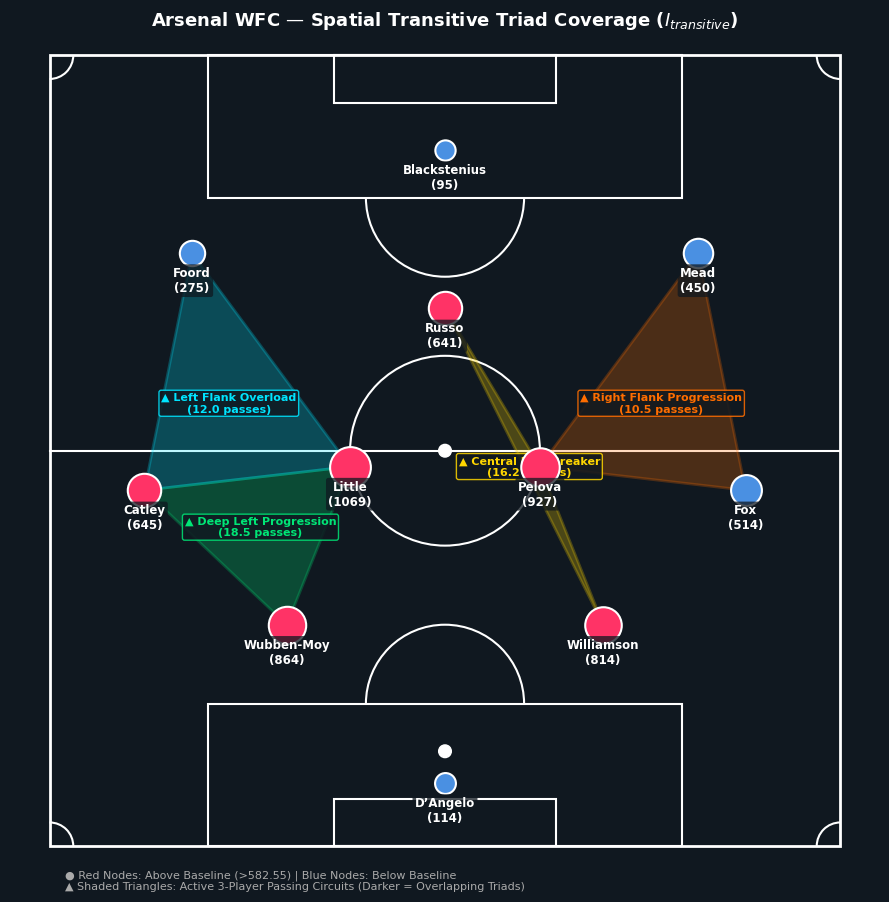

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, Arc, Polygon

players = {
    "Sabrina D’Angelo": {"pos": (50, 8), "score": 114.0},
    "Carlotte Wubben-Moy": {"pos": (30, 28), "score": 864.0},
    "Leah Williamson": {"pos": (70, 28), "score": 814.0},
    "Steph Catley": {"pos": (12, 45), "score": 645.0},
    "Emily Fox": {"pos": (88, 45), "score": 514.0},
    "Kim Little": {"pos": (38, 48), "score": 1069.0},
    "Victoria Pelova": {"pos": (62, 48), "score": 927.0},
    "Alessia Russo": {"pos": (50, 68), "score": 641.0},
    "Caitlin Foord": {"pos": (18, 75), "score": 275.0},
    "Beth Mead": {"pos": (82, 75), "score": 450.0},
    "Stina Blackstenius": {"pos": (50, 88), "score": 95.0},
}

TEAM_BASELINE = 582.55

# ==============================================================================
# 3. DEFINE KEY TRANSITIVE TRIADS TO VISUALIZE AS SHADED POLYGONS
# ==============================================================================
transitive_triads = [
    {
        "players": ("Carlotte Wubben-Moy", "Kim Little", "Steph Catley"),
        "label": "Deep Left Progression",
        "color": "#00E676",  # Bright Green
        "capacity": "18.5 passes",
    },
    {
        "players": ("Leah Williamson", "Victoria Pelova", "Alessia Russo"),
        "label": "Central Line-Breaker",
        "color": "#FFD600",  # Yellow
        "capacity": "16.2 passes",
    },
    {
        "players": ("Kim Little", "Steph Catley", "Caitlin Foord"),
        "label": "Left Flank Overload",
        "color": "#00E5FF",  # Cyan
        "capacity": "12.0 passes",
    },
    {
        "players": ("Victoria Pelova", "Emily Fox", "Beth Mead"),
        "label": "Right Flank Progression",
        "color": "#FF6D00",  # Orange
        "capacity": "10.5 passes",
    },
]


# ==============================================================================
# 4. DRAW PITCH & OVERLAY TRIADS + NODES
# ==============================================================================
fig, ax = plt.subplots(figsize=(9, 12))
fig.patch.set_facecolor("#101820")

# Draw the base vertical pitch
draw_vertical_pitch(ax=ax, pitch_color="#101820", line_color="#ffffff")


# 4a. Draw Filled Translucent Triangle Polygons
for triad in transitive_triads:
    p1, p2, p3 = triad["players"]
    color = triad["color"]

    # Extract (X, Y) coordinates for vertices
    coords = [players[p1]["pos"], players[p2]["pos"], players[p3]["pos"]]

    # Create translucent polygon patch
    poly = Polygon(
        coords,
        closed=True,
        facecolor=color,
        edgecolor=color,
        alpha=0.25,  # Semi-transparent to show overlapping density
        linewidth=2.0,
        linestyle="-",
        zorder=3,
    )
    ax.add_patch(poly)

    # Compute triangle centroid to anchor label badge
    centroid_x = sum([c[0] for c in coords]) / 3.0
    centroid_y = sum([c[1] for c in coords]) / 3.0

    ax.text(
        centroid_x,
        centroid_y,
        f"▲ {triad['label']}\n({triad['capacity']})",
        color=color,
        fontsize=8,
        ha="center",
        va="center",
        weight="bold",
        zorder=4,
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="#101820",
            edgecolor=color,
            linewidth=1,
            alpha=0.85,
        ),
    )


# 4b. Draw Player Nodes & Text Badges
for name, data in players.items():
    x, y = data["pos"]
    score = data["score"]

    # Size nodes relative to score
    node_size = (score / 1200.0) * 800 + 150

    # Color-code nodes based on Team Baseline threshold
    node_color = "#FF3366" if score >= TEAM_BASELINE else "#4A90E2"

    # Scatter Node Plot
    ax.scatter(
        x,
        y,
        s=node_size,
        c=node_color,
        edgecolors="white",
        linewidth=1.5,
        zorder=5,
    )

    # Player Name and Score Label
    ax.text(
        x,
        y - 3.5,
        f"{name.split()[-1]}\n({int(score)})",
        color="white",
        fontsize=8.5,
        ha="center",
        va="center",
        weight="bold",
        zorder=6,
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="#101820",
            edgecolor="none",
            alpha=0.75,
        ),
    )


# ==============================================================================
# 5. TITLE & ANNOTATION LEGEND
# ==============================================================================
ax.text(
    50,
    103,
    "Arsenal WFC — Spatial Transitive Triad Coverage ($I_{transitive}$)",
    color="white",
    fontsize=13,
    ha="center",
    va="bottom",
    weight="bold",
)

ax.text(
    2,
    -3,
    "● Red Nodes: Above Baseline (>582.55) | Blue Nodes: Below Baseline\n▲ Shaded Triangles: Active 3-Player Passing Circuits (Darker = Overlapping Triads)",
    color="#aaaaaa",
    fontsize=8,
    ha="left",
    va="top",
)

plt.tight_layout()
plt.show()